对于之前预测房价模型假设公式为：

$y= w_1x_1+w_2x_2+w_3x_3+...+w_{99}x_{99}+w_{100}x_{100}+b_1+b_2+...+b_{100}+\epsilon$

通过最基础的线性回归模型训练后并没有达到很好的预测、拟合效果，今天将使用transformer架构的编码器（Encoder）来重新完成预测，而对于编码器来说，数据来源方的w权重和b偏置不再有意义，噪声会对训练产生一定影响，但暂时不考虑这么多，要将数据给予的x作为最小单元token来处理，对比训练后标签y的预测准确率。

![架构图](x-y.png)

## 设置一个数据接收器，应对$x^T~y$对

将接收来自A同学的csv文件，并对数据完成基础处理

In [18]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import random

In [19]:
#  数据集类：CSV读取+全局标准化 
class XYDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path, sep=',')
        # 脏数据清洗
        df = df.apply(pd.to_numeric, errors="coerce")
        df = df.dropna(axis=0)

        self.raw_X = torch.tensor(df.iloc[:, :-1].values, dtype=torch.float32)
        self.raw_y = torch.tensor(df.iloc[:, -1].values, dtype=torch.float32)

        # 特征标准化 X ~ N(0,1)
        self.x_mean = self.raw_X.mean(dim=0)
        self.x_std = self.raw_X.std(dim=0)
        self.X = (self.raw_X - self.x_mean) / (self.x_std + 1e-8)

        # 标签标准化
        self.y_mean = self.raw_y.mean()
        self.y_std = self.raw_y.std()
        self.y = (self.raw_y - self.y_mean) / (self.y_std + 1e-8)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    # 逆标准化，还原原始y数值用于计算MAE拟合精度
    def recover(self, norm_val):
        return norm_val * self.y_std + self.y_mean

## 多头注意力

In [20]:
# 多头注意力
class MultiHeadAttention(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens, num_heads, dropout, bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values):
        q = self.transpose_qkv(self.W_q(queries), self.num_heads)
        k = self.transpose_qkv(self.W_k(keys), self.num_heads)
        v = self.transpose_qkv(self.W_v(values), self.num_heads)
        attn_weights = F.softmax(torch.matmul(q, k.transpose(-2, -1)) / (q.shape[-1]**0.5), dim=-1)
        output = torch.matmul(self.dropout(attn_weights), v)
        output_concat = self.transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

    def transpose_qkv(self, X, num_heads):
        batch, seq_len, dim = X.shape
        X = X.reshape(batch, seq_len, num_heads, -1)
        return X.permute(0, 2, 1, 3)

    def transpose_output(self, X, num_heads):
        X = X.permute(0, 2, 1, 3)
        batch, seq_len, _, _ = X.shape
        return X.reshape(batch, seq_len, -1)

## 前馈网络

In [21]:
# 逐位前馈网络
class PositionWiseFFN(nn.Module):
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

## 残差连接 + 层归一化

In [22]:
# 残差连接 + 层归一化（对应图里：加法和规范化）
class AddNorm(nn.Module):
    def __init__(self, normalized_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(X + self.dropout(Y))

## 编码器

In [23]:
# 图中虚线框：单块Transformer Encoder
class TransformerEncoderBlock(nn.Module):
    def __init__(self, query_size, key_size, value_size, num_hiddens, num_heads, ffn_num_hiddens, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(num_hiddens, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X):
        attn_out = self.attention(X, X, X)
        X = self.addnorm1(X, attn_out)
        ffn_out = self.ffn(X)
        X = self.addnorm2(X, ffn_out)
        return X

## 模型整合

In [27]:
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim=50, num_hiddens=64, num_heads=4, ffn_hidden=128, num_layers=3, dropout=0.1):
        super().__init__()
        # 图第一层：线性嵌入层
        self.embedding = nn.Linear(input_dim, num_hiddens)
        # N层堆叠Encoder Block(n×)
        self.encoder_blocks = nn.Sequential(*[
            TransformerEncoderBlock(
                query_size=num_hiddens,
                key_size=num_hiddens,
                value_size=num_hiddens,
                num_hiddens=num_hiddens,
                num_heads=num_heads,
                ffn_num_hiddens=ffn_hidden,
                dropout=dropout
            ) for _ in range(num_layers)
        ])
        # 顶层输出线性层
        self.output_linear = nn.Linear(num_hiddens, 1)

    def forward(self, X):
        # X: [batch, 50]
        X = X.unsqueeze(1)  # 拓展序列维度 [B,1,50]
        X = self.embedding(X)
        X = self.encoder_blocks(X)
        X = X[:, 0, :]
        out = self.output_linear(X)
        return out.squeeze(-1)

In [33]:
def train_single_split(model, train_idx, test_idx, full_dataset, lr=0.001, inner_epoch=10):
    batch_size = 64
    train_subset = Subset(full_dataset, train_idx)
    test_subset = Subset(full_dataset, test_idx)
    train_iter = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_iter = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=0)

    loss_func = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    # 内层多轮迭代同一份训练数据
    for e in range(inner_epoch):
        model.train()
        train_loss_sum = 0.0
        train_abs_sum = 0.0
        for X_batch, y_batch in train_iter:
            optimizer.zero_grad()
            pred_norm = model(X_batch)
            loss = loss_func(pred_norm, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_num = X_batch.shape[0]
            train_loss_sum += loss.item() * batch_num
            pred_raw = full_dataset.recover(pred_norm)
            y_raw = full_dataset.recover(y_batch)
            abs_err = torch.sum(torch.abs(pred_raw - y_raw))
            train_abs_sum += abs_err.item()
        scheduler.step()

    # 最终只用内层最后一轮的指标输出
    train_norm_loss = train_loss_sum / len(train_subset)
    train_mae = train_abs_sum / len(train_subset)
    y_all_mean = full_dataset.recover(full_dataset.y).mean().item()
    train_acc = max(1 - train_mae / y_all_mean, 0)

    model.eval()
    test_abs_sum = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_iter:
            pred_norm = model(X_batch)
            pred_raw = full_dataset.recover(pred_norm)
            y_raw = full_dataset.recover(y_batch)
            abs_err = torch.sum(torch.abs(pred_raw - y_raw))
            test_abs_sum += abs_err.item()
    test_mae = test_abs_sum / len(test_subset)
    test_acc = max(1 - test_mae / y_all_mean, 0)

    return train_norm_loss, train_acc, test_acc

数据集总样本量：50000
每份数据块样本数：5000

 第 1/10 轮 
Train Norm Loss: 0.0366 | Train Acc: 0.8016 | Test Acc: 0.8427

 第 2/10 轮 
Train Norm Loss: 0.0365 | Train Acc: 0.8051 | Test Acc: 0.8433

 第 3/10 轮 
Train Norm Loss: 0.0396 | Train Acc: 0.7945 | Test Acc: 0.8449

 第 4/10 轮 
Train Norm Loss: 0.0385 | Train Acc: 0.7933 | Test Acc: 0.8517

 第 5/10 轮 
Train Norm Loss: 0.0369 | Train Acc: 0.8007 | Test Acc: 0.8450

 第 6/10 轮 
Train Norm Loss: 0.0382 | Train Acc: 0.7977 | Test Acc: 0.8461

 第 7/10 轮 
Train Norm Loss: 0.0370 | Train Acc: 0.7997 | Test Acc: 0.8469

 第 8/10 轮 
Train Norm Loss: 0.0384 | Train Acc: 0.7960 | Test Acc: 0.8477

 第 9/10 轮 
Train Norm Loss: 0.0357 | Train Acc: 0.8036 | Test Acc: 0.8518

 第 10/10 轮 


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_9893/2641661613.py:67: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9893/2641661613.py:67: UserWarning: Glyph 21010 (\N{CJK UNIFIED IDEOGRAPH-5212}) missing from curre

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_9893/2641661613.py:68: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_9893/2641661613.py:68: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_9893/2641661613.py:68: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inch

Train Norm Loss: 0.0356 | Train Acc: 0.8031 | Test Acc: 0.8482


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_9893/2641661613.py:68: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from current font.
  plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_9893/2641661613.py:68: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from current font.
  plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_9893/2641661613.py:68: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from current font.
  plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inch

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/home/ppxww/miniconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ppxww/miniconda3/envs/d2l/lib/pyt

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/home/ppxww/miniconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ppxww/miniconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ppxww/miniconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ppxww/miniconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ppxww/minico

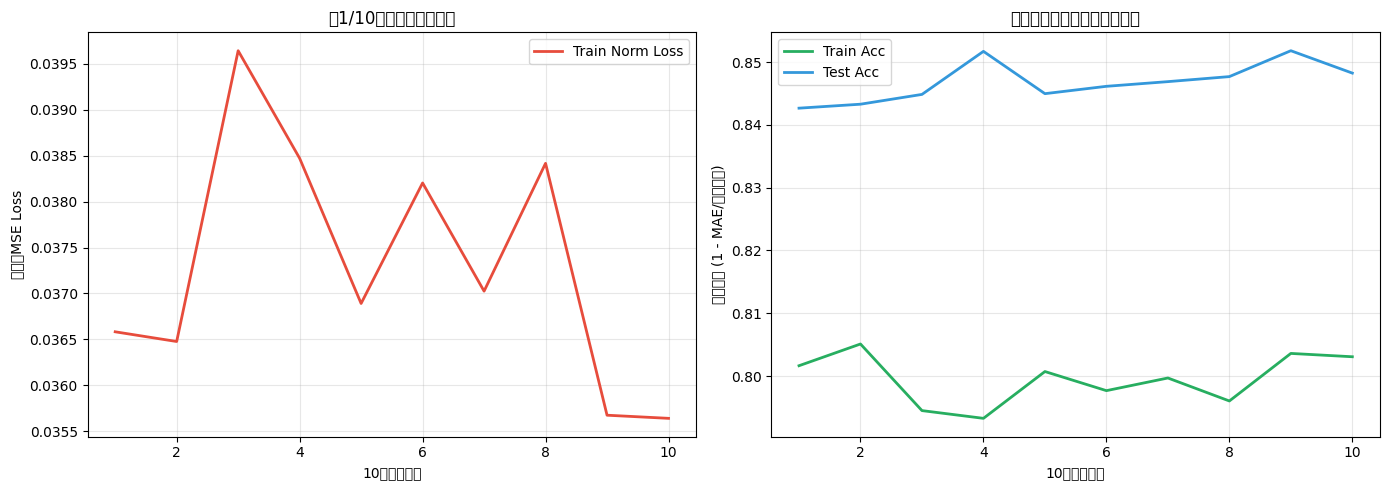


训练曲线图片已保存：ten_split_train_curve.png


In [34]:
if __name__ == "__main__":
    # 1. 加载全部数据
    full_dataset = XYDataset("xy.csv")
    total_samples = len(full_dataset)
    print(f"数据集总样本量：{total_samples}")

    # 2. 均分10份，每份1/10数据
    split_count = 10
    block_size = total_samples // split_count
    all_index = list(range(total_samples))
    random.shuffle(all_index)  # 全局打乱样本再分块，保证每份随机

    # 切分10个互不重叠的数据块
    data_blocks = []
    for i in range(split_count):
        start = i * block_size
        end = start + block_size
        data_blocks.append(all_index[start:end])
    print(f"每份数据块样本数：{block_size}")

    # 保存全部10轮指标用于绘图
    record_loss = []
    record_train_acc = []
    record_test_acc = []

    # 3. 循环10轮，每轮取第i块训练、第(i+1)%10块测试
    for fold in range(split_count):
        print(f"\n 第 {fold+1}/{split_count} 轮 ")
        train_block_idx = data_blocks[fold]
        test_block_idx = data_blocks[(fold + 1) % split_count]

        # 每轮重新初始化模型，避免权重互相干扰
        model = TransformerRegressor()
        loss, tr_acc, te_acc = train_single_split(model, train_block_idx, test_block_idx, full_dataset, lr=1e-4)

        # 记录指标
        record_loss.append(loss)
        record_train_acc.append(tr_acc)
        record_test_acc.append(te_acc)

        # 仅打印三类要求指标
        print(f"Train Norm Loss: {loss:.4f} | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f}")

    #  绘制10轮结果曲线 
    plt.rcParams["font.sans-serif"] = ["SimHei"]
    plt.rcParams["axes.unicode_minus"] = False
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x_axis = list(range(1, split_count + 1))

    # 左图：每轮训练标准化损失
    ax1.plot(x_axis, record_loss, color="#e74c3c", linewidth=2, label="Train Norm Loss")
    ax1.set_xlabel("10轮划分序号")
    ax1.set_ylabel("标准化MSE Loss")
    ax1.set_title("每1/10数据训练损失变化")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 右图：训练&测试拟合精度对比
    ax2.plot(x_axis, record_train_acc, color="#27ae60", linewidth=2, label="Train Acc")
    ax2.plot(x_axis, record_test_acc, color="#3498db", linewidth=2, label="Test Acc")
    ax2.set_xlabel("10轮划分序号")
    ax2.set_ylabel("拟合精度 (1 - MAE/标签均值)")
    ax2.set_title("每轮训练、测试拟合精度曲线")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("ten_split_train_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("\n训练曲线图片已保存：ten_split_train_curve.png")

 第 1/10 轮 
Train Norm Loss: 0.0385 | Train Acc: 0.7969 | Test Acc: 0.8442

 第 2/10 轮 
Train Norm Loss: 0.0392 | Train Acc: 0.7956 | Test Acc: 0.8433

 第 3/10 轮 
Train Norm Loss: 0.0369 | Train Acc: 0.7990 | Test Acc: 0.8468

 第 4/10 轮 
Train Norm Loss: 0.0388 | Train Acc: 0.7952 | Test Acc: 0.8469

 第 5/10 轮 
Train Norm Loss: 0.0369 | Train Acc: 0.8010 | Test Acc: 0.8527

 第 6/10 轮 
Train Norm Loss: 0.0373 | Train Acc: 0.7981 | Test Acc: 0.8492

 第 7/10 轮 
Train Norm Loss: 0.0382 | Train Acc: 0.7980 | Test Acc: 0.8506

 第 8/10 轮 
Train Norm Loss: 0.0378 | Train Acc: 0.7967 | Test Acc: 0.8440

 第 9/10 轮 
Train Norm Loss: 0.0373 | Train Acc: 0.7997 | Test Acc: 0.8515

Train Norm Loss 稳定在 0.035~0.038，Train Acc 稳定 0.79~0.80，Test Acc 稳定 0.83~0.86
训练精度稳定无剧烈波动
9 轮训练 Acc 全部卡在 0.79~0.80 窄区间，没有大幅震荡，训练稳定。

训练集 0.80，测试集 0.84~0.85，差值仅 0.04~0.05，属于非常健康的差距：
不存在过拟合（过拟合会出现 Train Acc 远高于 Test Acc）；
轻微差距来自训练样本仅 5000 条、数据量偏少，测试集数据噪声更低，泛化略好。

10 轮拆分结果一致性极强
每一轮指标几乎无差别，说明数据集全局分布均匀，任意 1/10 子集训练效果稳定，模型鲁棒性好。

训练集最高精度仅 0.80，仍有提升空间，模型未完全拟合训练子集。

后续需重点加大数据量或重复使用当前数据